# 08 — Programming languages

**Supplementary Figures 2, 3 and 4.**

GPT-4 was asked for the same numerical sequences in **seven languages** —
Mathematica, Matlab, Python, ArnoldC, JavaScript, C++ and R — across four
complexity tiers and several temperatures. The question these five panels answer
is whether a model that can state a sequence in one language can state it in
another, and whether the answer it gives is a *program* or a transcription of
the numbers it was shown.

That second point is what `no_compression_percentage` measures: the fraction of
the target sequence's numbers that appear literally in the answer. A model that
understood the sequence writes a rule; a model that did not writes the numbers
down. It is the same argument as the rest of the paper, run over languages
instead of models.

### Why this notebook exists

These five panels had **no runnable producer**. `24_PLOTS_paper.ipynb` draws
them, but it reads one input through an absolute path on somebody else's
machine:

    /Users/beto/Documents/Projects/medLLM/normalized_compressed_ArnoldC.csv

so it could not run here — and the lab's copy
(`AlgoDynLab/SuperintelligenceTest`, `05_PLOTS_paper.ipynb`) has the identical
line. The file it names has been in this repository the whole time. That one
path was the entire blocker, and it meant these were the last published figures
with nothing checking them.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd

from superarc import languages as L
from superarc import parity, plots_dir
from superarc.notebook import preview

pd.set_option("display.width", 120)
plots_dir()

PosixPath('/Users/alberto/Documents/projects/medLLM/outputs/latest')

## 1. The corpus

4130 answers. Seven languages, four complexity tiers, several temperatures per
cell.

In [2]:
results = L.concat_all_results()
print(f"{len(results)} answers, {results['language'].nunique()} languages")
results.groupby(["language", "complexity"]).size().unstack(fill_value=0)

4130 answers, 7 languages


complexity,1,2,3,4
language,,,,
ArnoldC,150,150,140,150
C++,150,150,140,150
JavaScript,150,150,140,150
Mathematica,150,150,140,150
Matlab,150,150,140,150
Python,150,150,140,150
R,150,150,140,150


## 2. The complexity swap, and why it is a function

The published notebook does this in cell 1:

```python
total_df['complexity'] = total_df['complexity'].replace({4: 3, 3: 4})
```

**in place.** Run the cell twice and the two hardest tiers swap back, silently.
This is the *third* occurrence of that exact hazard in this repository — the
other two are `superarc.timeseries.average_by_complexity` and cell 53 of
`22_Timeseries_LLM_experiments.ipynb`, where it demonstrably fired and left the
committed notebook outputs disagreeing with the printed paper.

`swap_hardest_tiers` returns a copy, so applying it twice is visible rather than
silent.

In [3]:
swapped = L.swap_hardest_tiers(results)

pd.DataFrame({
    "as loaded": results["complexity"].value_counts().sort_index(),
    "swapped": swapped["complexity"].value_counts().sort_index(),
    "swapped twice": L.swap_hardest_tiers(swapped)["complexity"].value_counts().sort_index(),
})

,as loaded,swapped,swapped twice
complexity,,,
1,1050,1050,1050
2,1050,1050,1050
3,980,1050,980
4,1050,980,1050


## 3. The table the first two panels are drawn from

Percentage of answers that executed correctly, by language and complexity. This
is the number behind both the heatmap and the bar chart.

In [4]:
tiers = swapped[swapped["complexity"].isin([1, 2, 3])]
(tiers.groupby(["language", "complexity"])["correct_execution"].mean() * 100).unstack().round(1)

complexity,1,2,3
language,,,
ArnoldC,5.3,0.7,5.3
C++,10.0,8.0,57.3
JavaScript,100.0,50.7,42.0
Mathematica,100.0,43.3,0.7
Matlab,98.7,44.7,99.3
Python,100.0,33.3,6.7
R,100.0,23.3,64.7


## 4. The figures

All five are written by one call. Output goes to `plots_dir()` — the
git-ignored `outputs/latest/` unless `SUPERARC_PLOTS_DIR` says otherwise — never
to `plots/`.

In [5]:
written = L.produce()
for path in written:
    print(path.name)

figure11-top.pdf
figure11-top.svg
figure11_bottom.pdf
figure11_bottom.svg
figure12-bottom.pdf
figure12-bottom.svg
figure12-top.pdf
figure12-top.svg
figure13.pdf
figure13.svg


### Supplementary Figure 2 — top

Correct executions beside the share of those that were *prints*. The orange bars
are the answers that reproduced the sequence by printing it rather than
computing it.

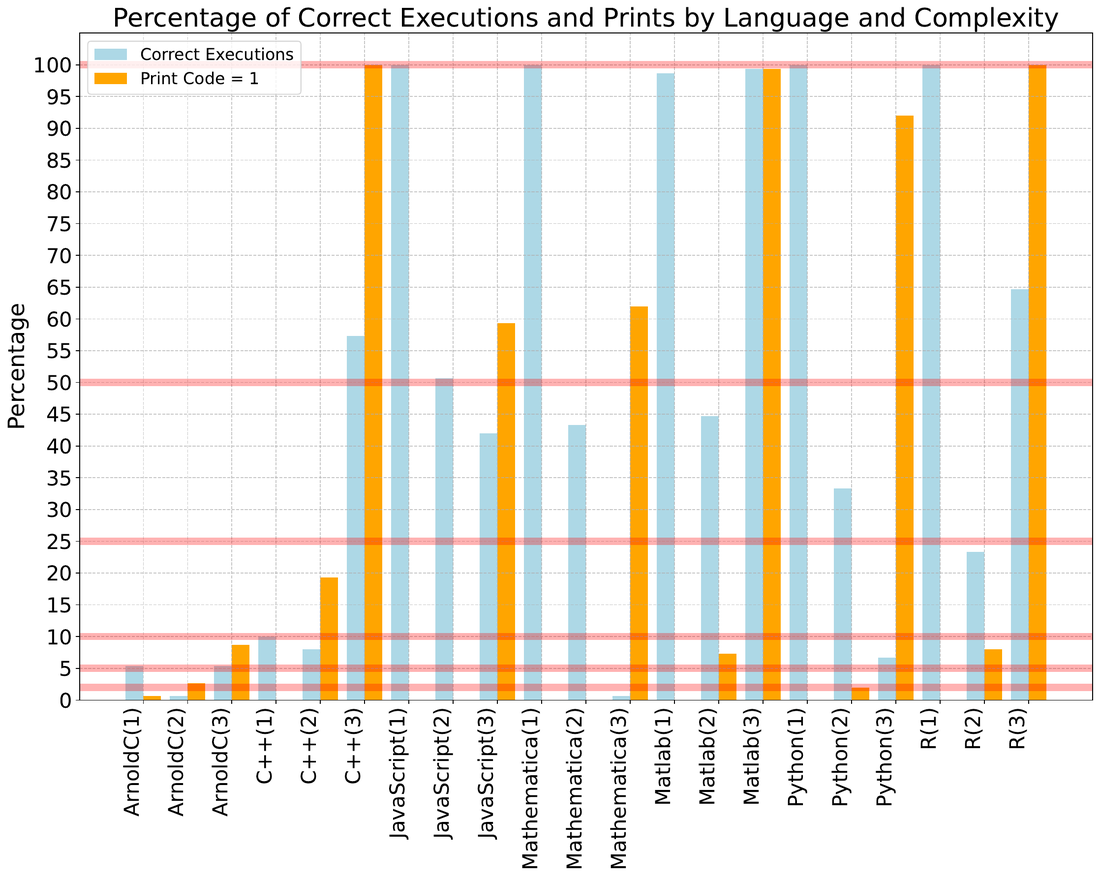

In [6]:
preview(parity.rasterise(plots_dir() / "figure11-top.pdf"))

### Supplementary Figure 3 — top

The same correctness, as a heatmap.

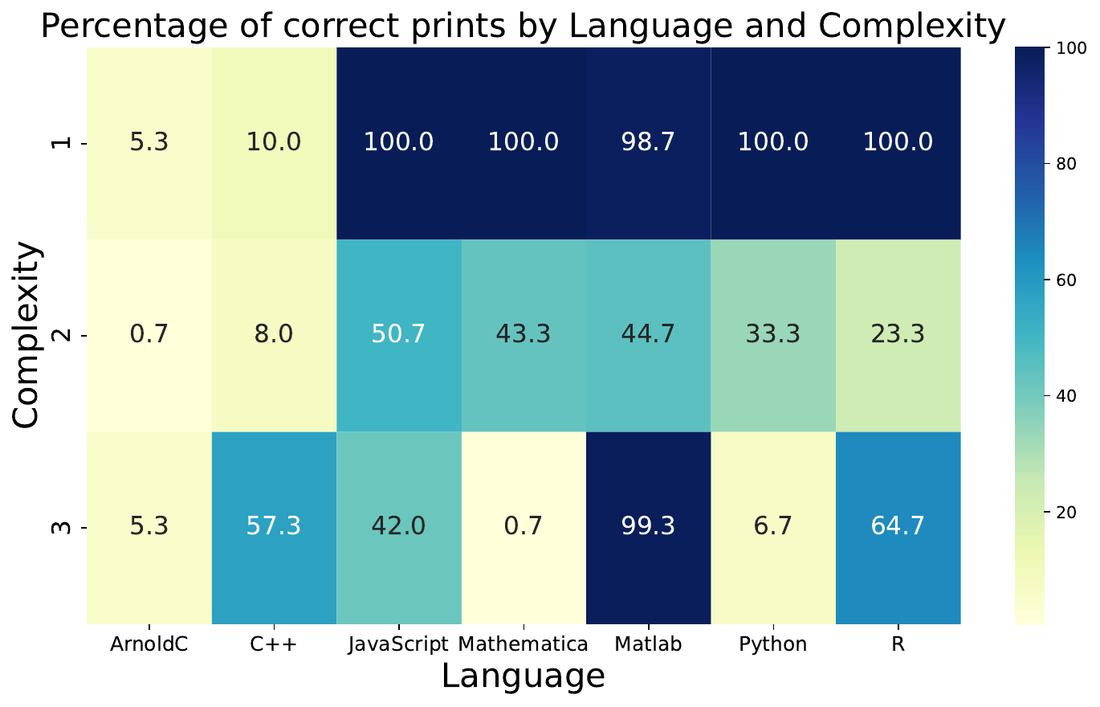

In [7]:
preview(parity.rasterise(plots_dir() / "figure12-top.pdf"))

### Supplementary Figure 4

No-compression percentage against complexity, per language, shaded by
temperature. Rising lines mean the answers contain more of the target's literal
numbers as the sequence gets harder.

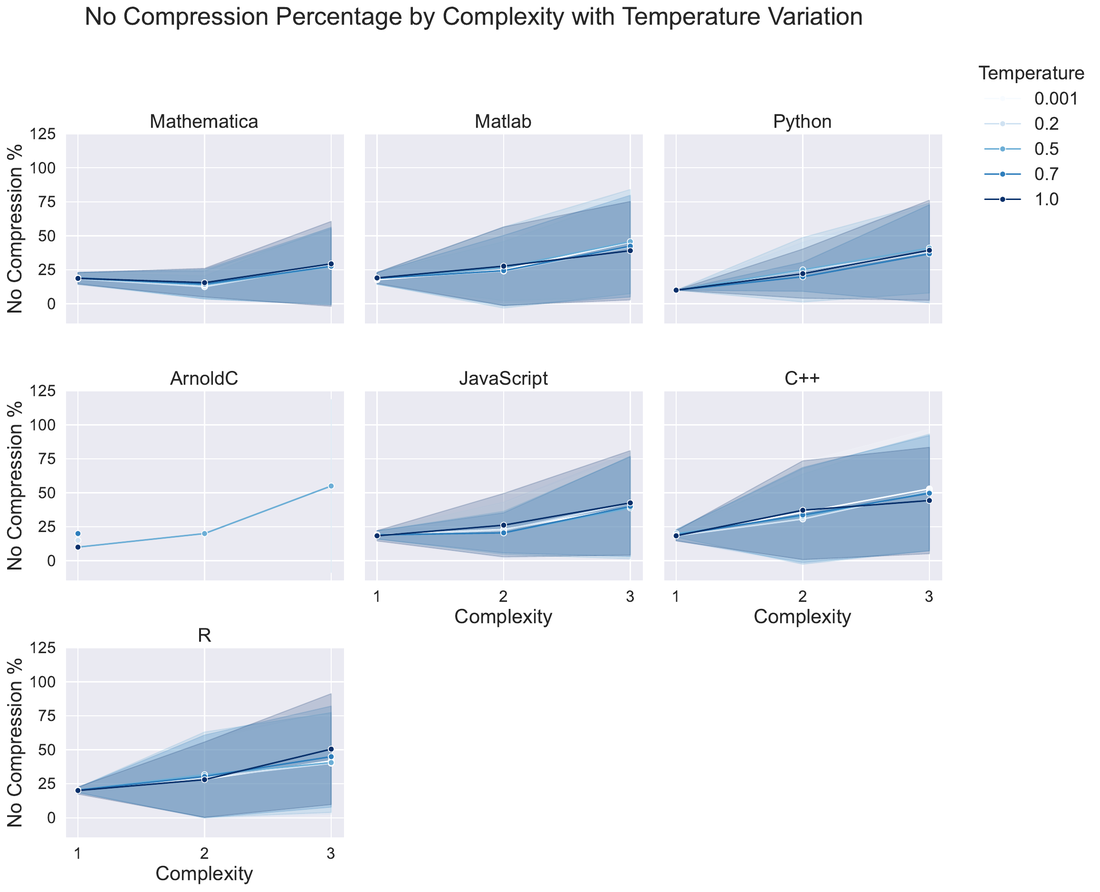

In [8]:
preview(parity.rasterise(plots_dir() / "figure13.pdf"))

### Supplementary Figure 3 — bottom

The same measure on a log scale, all languages on one axis.

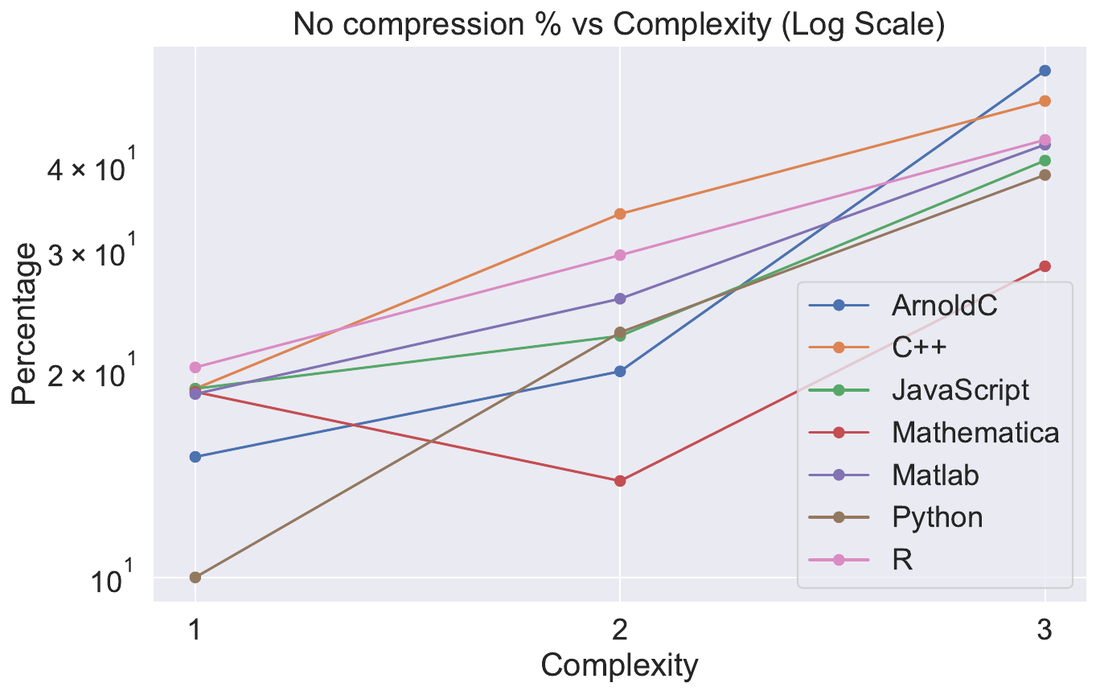

In [9]:
preview(parity.rasterise(plots_dir() / "figure12-bottom.pdf"))

### Supplementary Figure 2 — bottom, and the one figure that cannot be recovered

Which sequences each language got right, as a `supervenn`. **Its numbers are
reproducible; its layout is not.**

The inputs are Python `set` objects holding sequence *strings*. Python
randomises string hashing per process, so set iteration order changes from run
to run, and `sets_ordering='minimize gaps'` is a heuristic over that order.
Three separate processes produced packings differing by 15.7%, 24.8% and 25.7%
— on identical code and identical data.

A first pass called this a library-version difference, on the strength of two
runs that agreed exactly. Those two runs shared a process, and therefore shared
a hash seed, which is the one thing that varies. With `PYTHONHASHSEED=0` two
separate processes agree at 0.0000%, which is why `superarc.parity` pins it.

So this panel joins the bootstrap tiers and Supplementary Figure 1: the
published image depends on a draw nobody recorded — here a hash seed rather than
an RNG seed — and cannot be recovered.

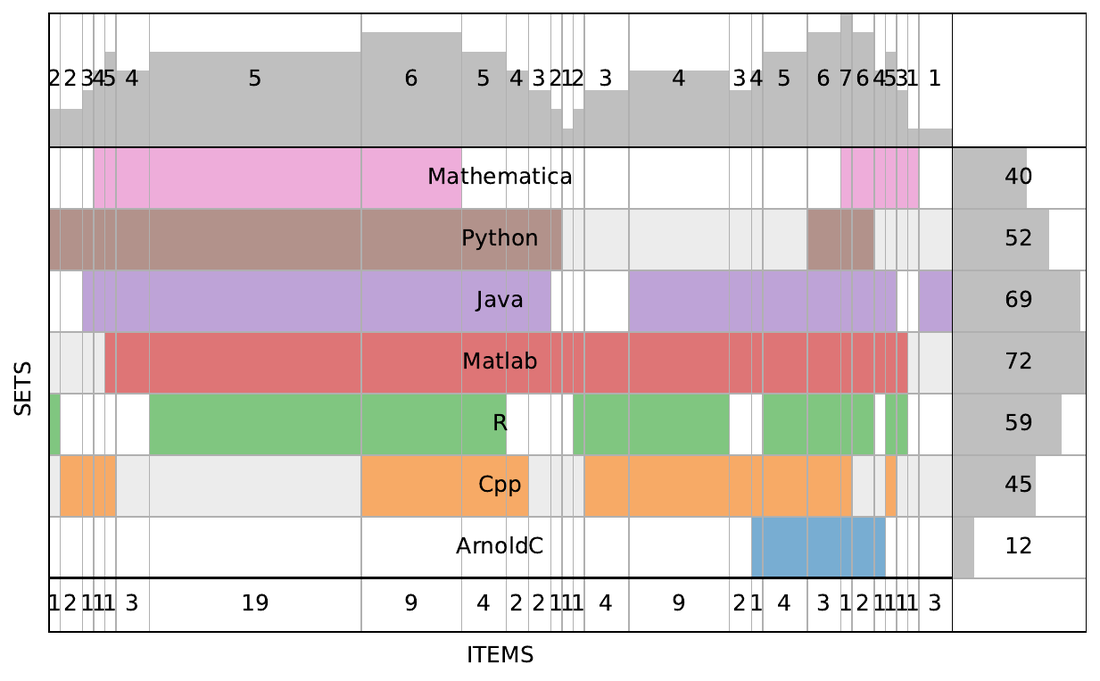

In [10]:
preview(parity.rasterise(plots_dir() / "figure11_bottom.pdf"))

What *is* pinned to the published figure is the data underneath it. All seven
set sizes match the printed panel exactly, in the same row order.

In [11]:
import copy

def correct_sequences(frame, language):
    df = copy.deepcopy(frame[frame["language"] == language])
    return set(df[(df["correct_execution"] == True) & (df["complexity"] != 4)]["sequence"].unique())

pd.DataFrame({
    "sequences solved": {
        label: len(correct_sequences(swapped, lang))
        for label, lang in zip(L.SUPERVENN_LABELS, L.SUPERVENN_LANGUAGES)
    },
    "printed in the paper": {"Mathematica": 40, "R": 59, "Matlab": 72, "Python": 52,
                             "Cpp": 45, "Java": 69, "ArnoldC": 12},
})

,sequences solved,printed in the paper
Mathematica,40,40
R,59,59
Matlab,72,72
Python,52,52
Cpp,45,45
Java,69,69
ArnoldC,12,12


## 5. Does it still match what was published?

Four of the five reproduce pixel for pixel. The fifth is the supervenn panel
above, whose packing depends on an unrecorded hash seed.

In [12]:
parity.check_figures([
    "figure11-top.pdf",
    "figure12-top.pdf",
    "figure12-bottom.pdf",
    "figure13.pdf",
    "figure11_bottom.pdf",
])

,figure,status,detail
0,SI Fig 2 top executions and prints by language,matches published,0.0000% of pixels differ
1,SI Fig 3 top correct prints heatmap,matches published,0.0000% of pixels differ
2,"SI Fig 3 bottom no-compression, log scale",matches published,0.0000% of pixels differ
3,SI Fig 4 no-compression by language and tempe...,matches published,0.0000% of pixels differ
4,figure11_bottom.pdf,changed,SI Fig 2 bottom sequence overlap by language ...


### And it left the published artifacts alone

Everything above wrote to `plots_dir()`. Nothing touched `plots/` or
`new_plots/`, and nothing rewrote the seven committed
`normalized_compressed_*.csv` — the published chain did rewrite those, because
`analyze_all_languages` passed `save_language_name` for every language.
`L.analysis` does not, by default.

In [13]:
import subprocess
changed = subprocess.run(
    ["git", "status", "--porcelain", "plots", "new_plots", "."],
    capture_output=True, text=True, cwd="..",
).stdout
tracked = [l for l in changed.splitlines() if "normalized_compressed" in l
           or l.split()[-1].startswith(("plots/", "new_plots/"))]
print("\n".join(tracked) if tracked else "clean: no published artifact or committed CSV was modified")

clean: no published artifact or committed CSV was modified
